In [7]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [8]:
def read_json_file(file_loc):
    with open(f"{file_loc}/runhistory.json") as f:
        runhistory = json.load(f)
    with open(f"{file_loc}/intensifier.json") as f:
        intensifier = json.load(f)

    return runhistory, intensifier

In [9]:
hist, inten = read_json_file("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

print(len(hist["configs"]))

6


# 9600 Captime Utility

In [10]:
def make_line_plot_over_time(file_loc):
    hist, inten = read_json_file(file_loc)

    n_configs = len(hist["configs"])

    all_config_runtimes = {config_id:[] for config_id in range(1, n_configs+1)}
    all_config_cost = {config_id:[] for config_id in range(1, n_configs+1)}

    # Actually not compltely fair as we might compare 1 and 2 on 2 instances and then 1 wins, but later the average still becomes lower

    for run in hist["data"]:
        conf_id = run["config_id"]
        all_config_runtimes[conf_id].append(run["time"])
        all_config_cost[conf_id].append(run["cost"])

    # print(all_config_runtimes)
    # print(all_config_cost)

    runt_arr = [np.mean(all_runtimes) for all_runtimes in all_config_runtimes.values()]
    cost_arr = [np.mean(all_runtimes) for all_runtimes in all_config_cost.values()]
    # print(runt_arr)
    # print(cost_arr)

    how_many = [len(all_runtimes) for all_runtimes in all_config_cost.values()]
    # print(how_many)

    plt.plot(runt_arr)
    plt.xlabel("Config")
    plt.ylabel("Average Runtime")
    plt.show()
    plt.plot(cost_arr)
    plt.xlabel("Config")
    plt.ylabel("1 - Utility")
    plt.show()

    plt.bar(list(range(0, n_configs)), how_many)
    plt.xlabel("Config")
    plt.ylabel("Instances evaluated")
    plt.show()



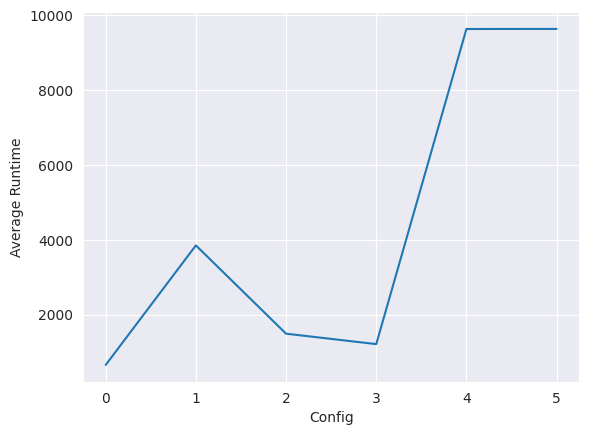

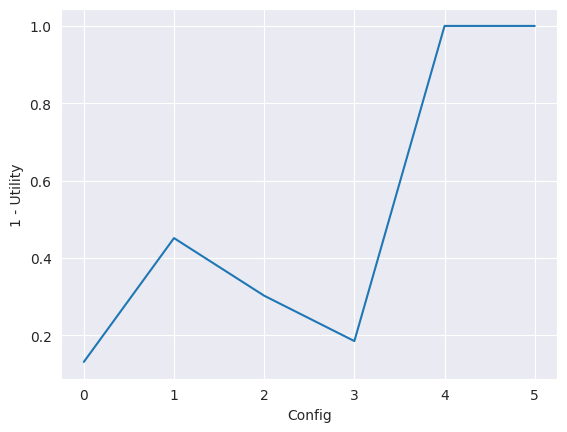

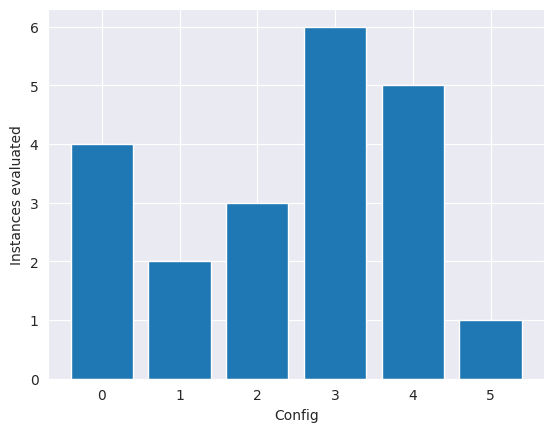

In [11]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

So this is kinda a problem, as some really do need a new one, so maybe we should add th eidea of intesification with at least adding 1 to the currect incumbent as we can see that on the first 4 isntances the average is lower on config 4, but then it become hhigher because of a later instance.

In [118]:
from dotenv import load_dotenv
import os
from ConfigSpace.read_and_write import pcs_new
from pandas import json_normalize
import ConfigSpace.hyperparameters.categorical
load_dotenv()

def get_cat_cont():
    param_file_loc = os.getenv('PARAM_FILE_LOC')
    with open(param_file_loc, 'r') as fh:
        casmo_configspace = pcs_new.read(fh)
    casmo_configspace.seed(721)
    # print(casmo_configspace)

    import ConfigSpace.hyperparameters.categorical
    cont_names = set()
    cat_names = set()

    int_names = []
    #TODO: make a default section here? can just get from configspace as well i think

    # print(dict(deserialized_conf))
    for index, (name, obj) in enumerate(dict(casmo_configspace).items()):

        if type(obj) == ConfigSpace.hyperparameters.categorical.CategoricalHyperparameter:

            cat_names.add(name)

        elif type(obj) == ConfigSpace.hyperparameters.uniform_integer.UniformIntegerHyperparameter:
            cont_names.add(name)

        elif type(obj) == ConfigSpace.hyperparameters.uniform_float.UniformFloatHyperparameter:
            cont_names.add(name)

        else:
            print(f"unknown: {obj}")

    # print(cont_names)
    # print(cat_names)
    return cont_names, cat_names, casmo_configspace

def build_hamming_dist_mat(config_table, cat_names):
    print(cat_names)
    # print(len(config_table))
    dists = np.zeros((len(config_table), len(config_table)))
    # print(dists.shape)
    for i in range(dists.shape[0]):
        for j in range(i+1, dists.shape[1]):
            # print(config_table.iloc[i])
            # print(config_table.iloc[i]["auto_issmethod_on"])
            # print(config_table.iloc[i]["auto_barhomogeneous"])
            # print(config_table.iloc[j]["auto_barhomogeneous"])

            for cat_var in cat_names:
                # print("-------------------")
                # print(config_table.iloc[i][cat_var])
                # print(config_table.iloc[j][cat_var])
                # print(type(config_table.iloc[i][cat_var]))
                # print(type(config_table.iloc[j][cat_var]))
                if config_table.iloc[i][cat_var] != config_table.iloc[j][cat_var]:
                    # print(config_table.iloc[i][cat_var])
                    # print(config_table.iloc[j][cat_var])
                    if not pd.isnull(config_table.iloc[i][cat_var]) and not pd.isnull(config_table.iloc[j][cat_var]):
                    # print("different")
                    # print(config_table.iloc[i][cat_var])
                    # print(config_table.iloc[j][cat_var])
                        dists[i,j] += 1
                    # print(cat_var)
                    # print(config_table.iloc[i][cat_var])
                    # print(config_table.iloc[j][cat_var])
            # break
    return dists

def build_euc_dist_mat_normalized(configspace, config_table, cont_names):

    def min_max_normalized(value, min_val, max_val):
        return (value - min_val)/(max_val-min_val)

    # print(len(config_table))
    dists = np.zeros((len(config_table), len(config_table)))
    # print(dists.shape)
    for i in range(dists.shape[0]):
        for j in range(i, dists.shape[1]):

            for con_var in cont_names:
                try:

                    var_min = configspace[con_var].lower
                    var_max = configspace[con_var].upper
                    # print("--------------")
                    # print((config_table.iloc[i][con_var]))
                    # print((config_table.iloc[j][con_var]))
                    if pd.isnull(config_table.iloc[i][con_var]) or pd.isnull(config_table.iloc[i][con_var]):
                        continue

                    dists[i,j] += (min_max_normalized(config_table.iloc[i][con_var], var_min, var_max) - min_max_normalized(config_table.iloc[j][con_var], var_min, var_max)) ** 2
                except Exception as e:
                    print(e)
                    print(f"Variable not found?: {con_var}")


                # dists[i,j] += (config_table.iloc[i][con_var] - config_table.iloc[j][con_var]) ** 2
    return np.sqrt(dists)

def make_distance_plot(file_loc):
    hist, inten = read_json_file(file_loc)

    all_configs_json = hist["configs"]
    config_frame = pd.DataFrame.from_dict(all_configs_json).T
    # print(config_frame.T)
    # print(config_frame.dtypes)
    cont_names, cat_names, casmo_configspace= get_cat_cont()
    dist_mat = build_hamming_dist_mat(config_frame, cat_names)
    # print(dist_mat)
    sns.heatmap(dist_mat + dist_mat.T, cmap="PuOr")
    plt.show()

    dist_mat = build_euc_dist_mat_normalized(casmo_configspace, config_frame, cont_names)
    sns.heatmap(dist_mat + dist_mat.T, cmap="PuOr")
    plt.show()


/tmp/ipykernel_10970/485939348.py:11: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


{'auto_projimpliedcuts_on', 'partitionplace', 'barorder', 'aggregate', 'auto_mircuts_on', 'auto_disconnected_on', 'auto_networkcuts_on', 'auto_varbranch_on', 'auto_strongcgcuts_on', 'auto_zeroobjnodes_on', 'auto_minrelnodes_on', 'shut_off_mip_start_processing', 'auto_cutpasses_on', 'auto_presparsify_on', 'auto_branchdir_on', 'siftmethod', 'branchdir', 'precrush', 'quad', 'auto_infproofcuts_on', 'barhomogeneous', 'auto_cliquecuts_on', 'auto_quad_on', 'auto_mipsepcuts_on', 'auto_rltcuts_on', 'presparsify', 'infunbdinfo', 'auto_barhomogeneous', 'auto_sifting_on', 'dualreductions', 'auto_aggfill_on', 'auto_cuts_on', 'auto_submipcuts_on', 'nodemethod', 'auto_normadjust_on', 'varbranch', 'auto_nodemethod_on', 'auto_degenmoves_on', 'mipfocus', 'crossover', 'auto_cutaggpasses_on', 'predual', 'auto_relaxliftcuts_on', 'auto_predual_on', 'auto_crossover', 'auto_startnodelimit', 'auto_pumppasses_on', 'auto_modkcuts_on', 'auto_barorder', 'auto_presolve_on', 'auto_rins_on', 'auto_symmetry_on', 'auto

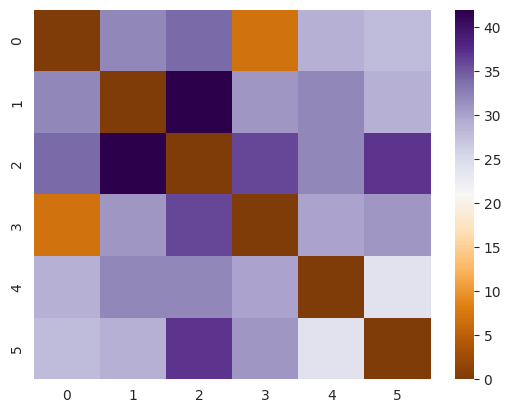

'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Varia

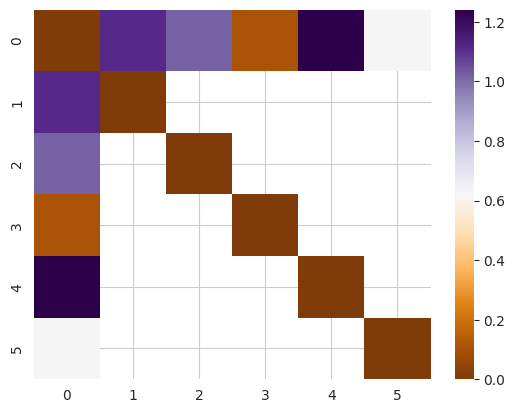

In [117]:
make_distance_plot("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

In [67]:
def compare_encumbent_to_first(file_loc):
    hist, inten = read_json_file(file_loc)

    n_configs = len(hist["configs"])

    all_config_runtimes = {config_id:[] for config_id in range(1, n_configs+1)}
    all_config_cost = {config_id:[] for config_id in range(1, n_configs+1)}

    # Actually not compltely fair as we might compare 1 and 2 on 2 instances and then 1 wins, but later the average still becomes lower

    for run in hist["data"]:
        conf_id = run["config_id"]
        all_config_runtimes[conf_id].append(run["time"])
        all_config_cost[conf_id].append(run["cost"])

    incumbent_ids = inten["incumbent_ids"]
    first_encumbent = incumbent_ids[0]

    plt.scatter(all_config_runtimes[1], all_config_runtimes[int(first_encumbent)][:len(all_config_runtimes[1])], alpha=0.3, s=10)
    plt.xlabel("Runtime Default")
    plt.ylabel("Runtime Incumbent")
    plt.show()

    plt.scatter(all_config_cost[1], all_config_cost[int(first_encumbent)][:len(all_config_cost[1])],  alpha=0.3, s=10)
    plt.xlabel("Cost Default")
    plt.ylabel("Cost Incumbent")
    plt.show()

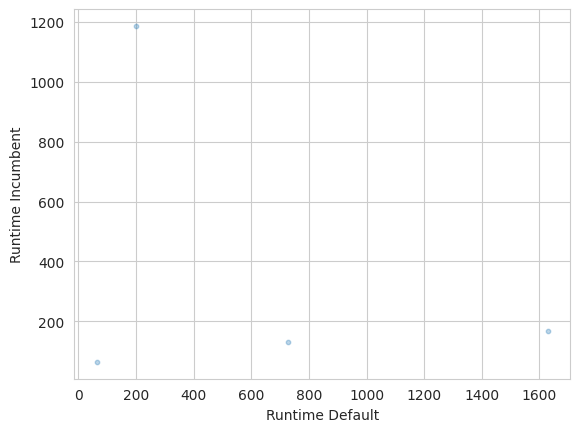

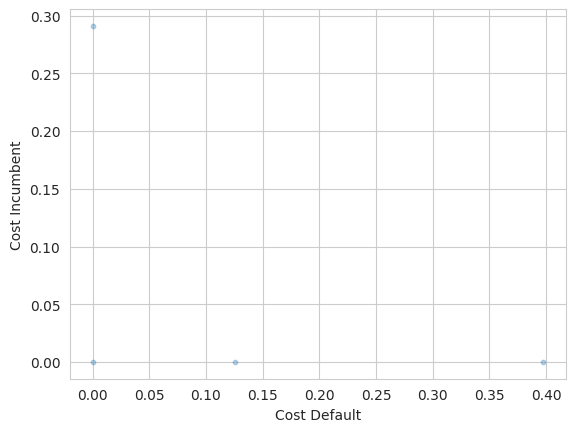

In [68]:
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

So there is definetly a very large difference somewhere in how smac3 compares to smac2 as it only uses 4 isntances here to make a decision instead of the (dont know how many) used in smac2.... Probably something to do with the decreased cutoffs somewhere is smac 2? but there is no clear documentation as to why this is the case? so smac2 would maybe be better, even though smac3 works as we expect it to work..

# 3600 captime utility


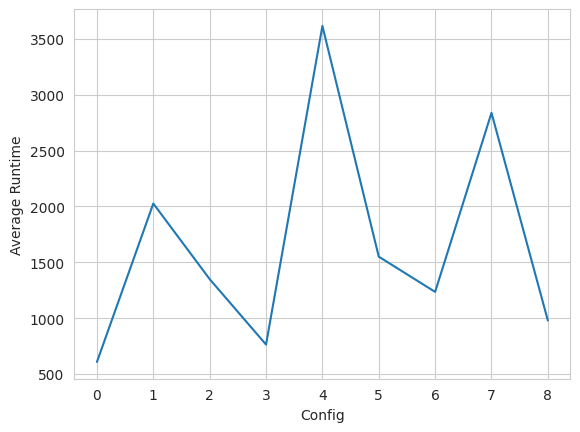

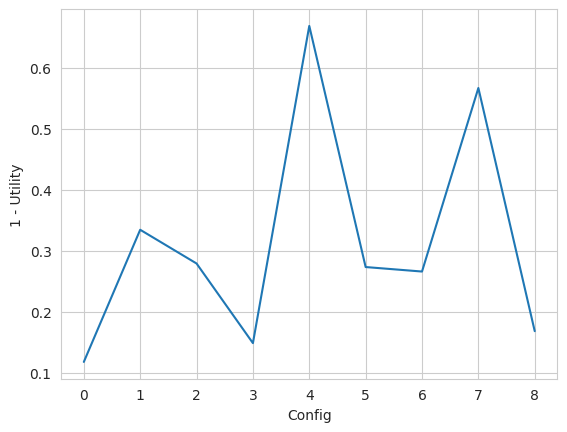

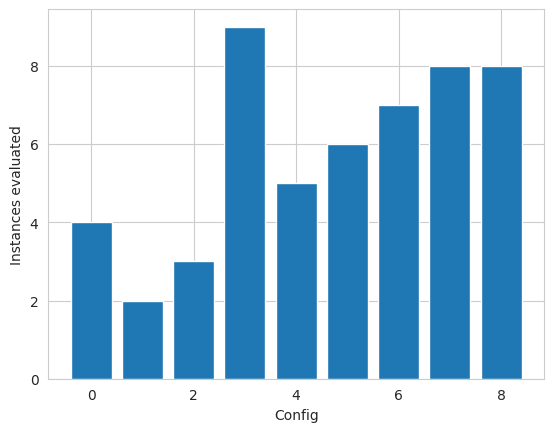

In [69]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify/0/")

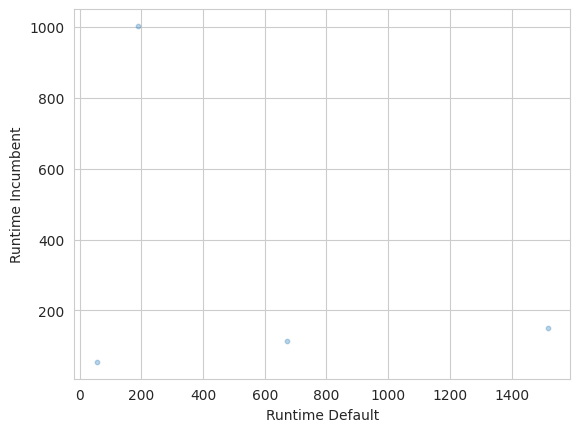

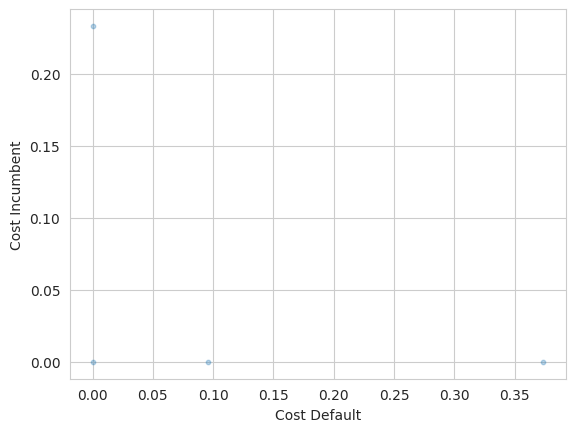

In [70]:
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify/0/")

aggregate              object
auto_aggfill_on        object
auto_barcorrectors     object
auto_barhomogeneous    object
auto_barorder          object
                        ...  
impliedcuts            object
presolve               object
gubcovercuts           object
startnodelimit         object
strongcgcuts           object
Length: 111, dtype: object
{'auto_projimpliedcuts_on', 'partitionplace', 'barorder', 'aggregate', 'auto_mircuts_on', 'auto_disconnected_on', 'auto_networkcuts_on', 'auto_varbranch_on', 'auto_strongcgcuts_on', 'auto_zeroobjnodes_on', 'auto_minrelnodes_on', 'shut_off_mip_start_processing', 'auto_cutpasses_on', 'auto_presparsify_on', 'auto_branchdir_on', 'siftmethod', 'branchdir', 'precrush', 'quad', 'auto_infproofcuts_on', 'barhomogeneous', 'auto_cliquecuts_on', 'auto_quad_on', 'auto_mipsepcuts_on', 'auto_rltcuts_on', 'presparsify', 'infunbdinfo', 'auto_barhomogeneous', 'auto_sifting_on', 'dualreductions', 'auto_aggfill_on', 'auto_cuts_on', 'auto_submipcuts_on', '

/tmp/ipykernel_10970/347920964.py:11: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


[[ 0. 32. 34.  7. 29. 28. 29. 26. 24.]
 [ 0.  0. 42. 31. 32. 29. 31. 35. 38.]
 [ 0.  0.  0. 36. 32. 37. 33. 29. 32.]
 [ 0.  0.  0.  0. 30. 31. 29. 30. 22.]
 [ 0.  0.  0.  0.  0. 24. 36. 32. 28.]
 [ 0.  0.  0.  0.  0.  0. 36. 33. 29.]
 [ 0.  0.  0.  0.  0.  0.  0. 31. 35.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 33.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]]


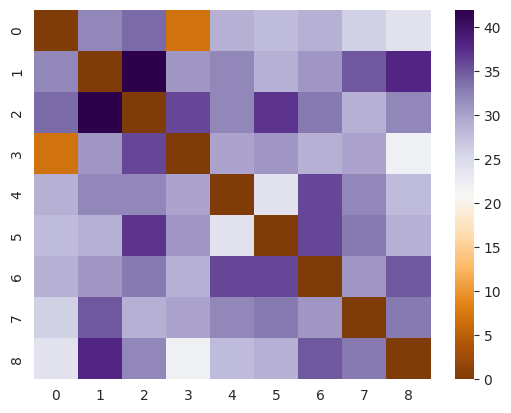

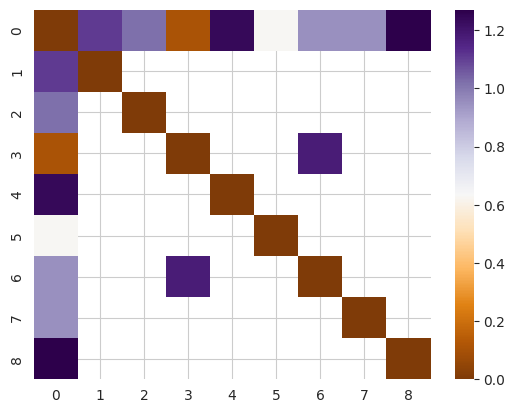

In [110]:
make_distance_plot("./storage_alice/smac3_output/smac3_mipverify/0/")

# 9600 captime Par

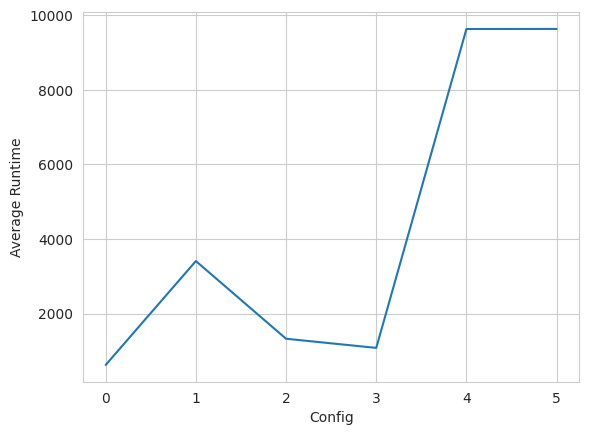

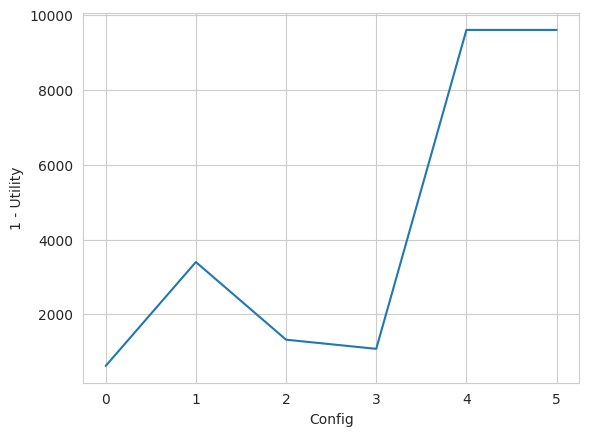

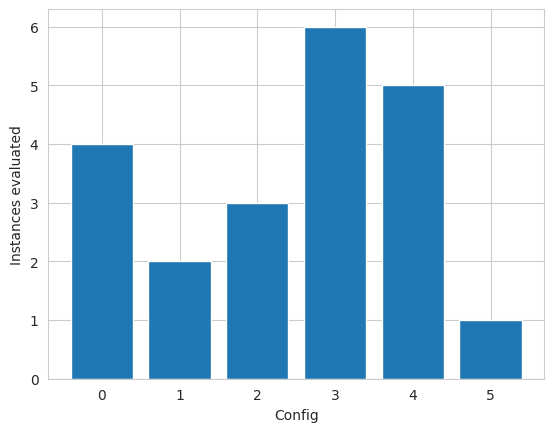

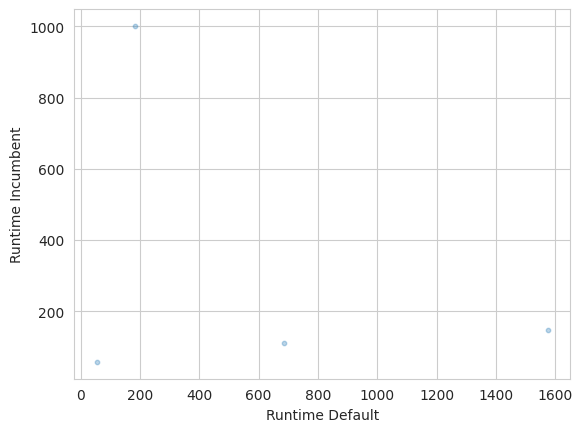

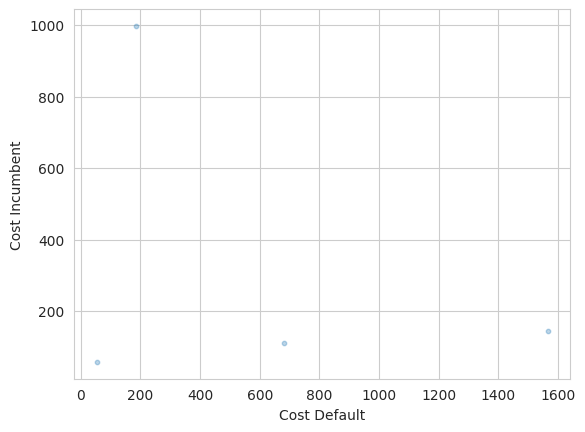

In [72]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff9600/0/")
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff9600/0/")

/tmp/ipykernel_10970/2247171791.py:11: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


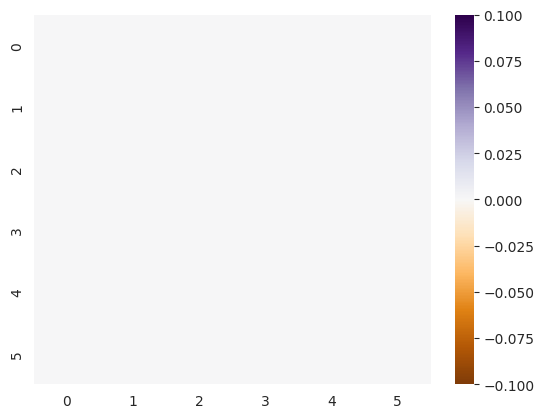

'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Variable not found?: strongcgcuts
'strongcgcuts'
Varia

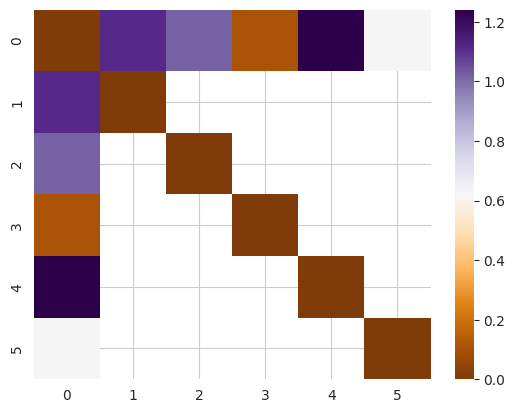

In [73]:
make_distance_plot("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff9600/0/")

# 3600 Captime PAR

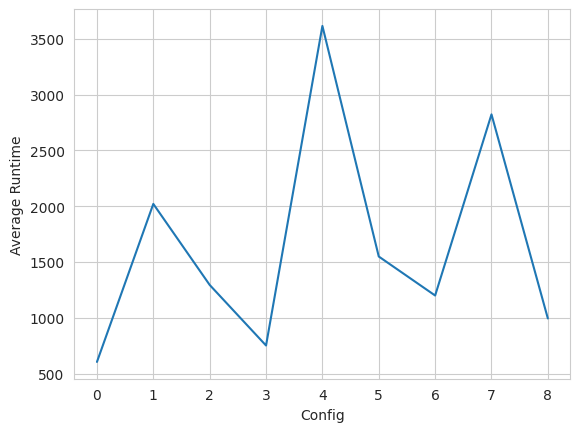

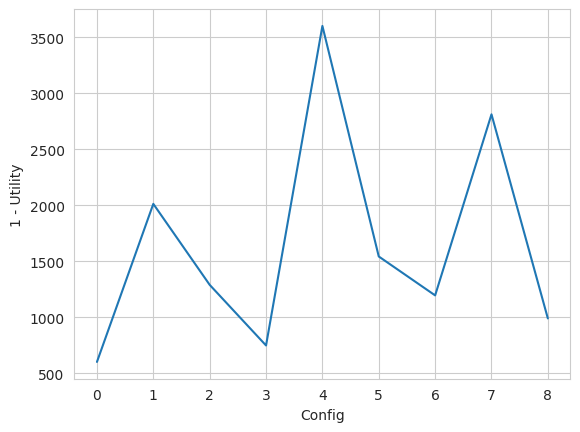

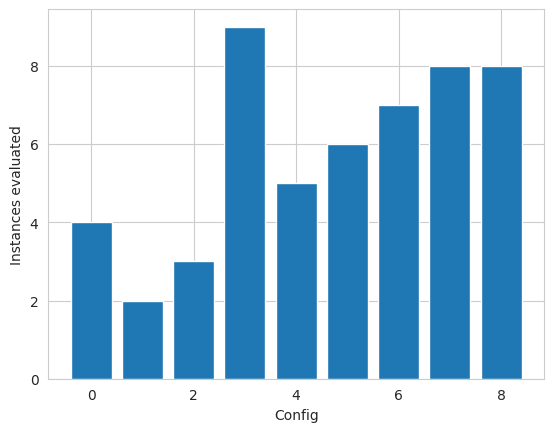

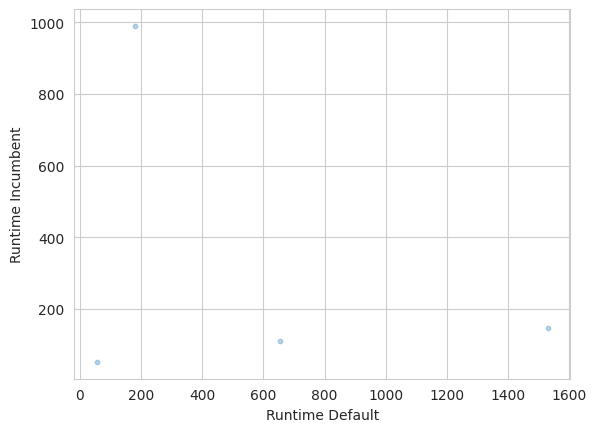

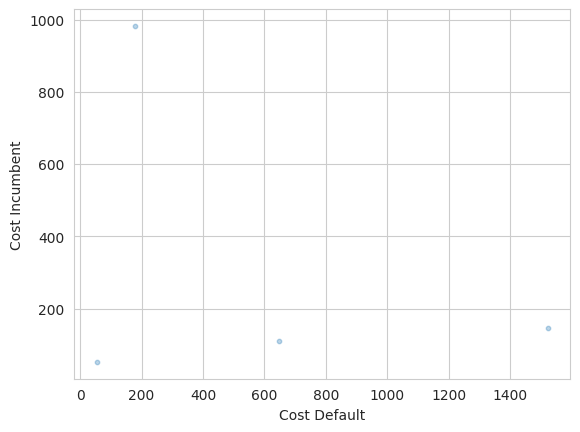

In [74]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff3600/0/")
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff3600/0/")

aggregate              object
auto_aggfill_on        object
auto_barcorrectors     object
auto_barhomogeneous    object
auto_barorder          object
                        ...  
impliedcuts            object
presolve               object
gubcovercuts           object
startnodelimit         object
strongcgcuts           object
Length: 111, dtype: object
{'auto_projimpliedcuts_on', 'partitionplace', 'barorder', 'aggregate', 'auto_mircuts_on', 'auto_disconnected_on', 'auto_networkcuts_on', 'auto_varbranch_on', 'auto_strongcgcuts_on', 'auto_zeroobjnodes_on', 'auto_minrelnodes_on', 'shut_off_mip_start_processing', 'auto_cutpasses_on', 'auto_presparsify_on', 'auto_branchdir_on', 'siftmethod', 'branchdir', 'precrush', 'quad', 'auto_infproofcuts_on', 'barhomogeneous', 'auto_cliquecuts_on', 'auto_quad_on', 'auto_mipsepcuts_on', 'auto_rltcuts_on', 'presparsify', 'infunbdinfo', 'auto_barhomogeneous', 'auto_sifting_on', 'dualreductions', 'auto_aggfill_on', 'auto_cuts_on', 'auto_submipcuts_on', '

/tmp/ipykernel_10970/347920964.py:11: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


[[ 0. 32. 34.  7. 29. 28. 29. 26. 24.]
 [ 0.  0. 42. 31. 32. 29. 31. 35. 38.]
 [ 0.  0.  0. 36. 32. 37. 33. 29. 32.]
 [ 0.  0.  0.  0. 30. 31. 29. 30. 22.]
 [ 0.  0.  0.  0.  0. 24. 36. 32. 28.]
 [ 0.  0.  0.  0.  0.  0. 36. 33. 29.]
 [ 0.  0.  0.  0.  0.  0.  0. 31. 35.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 33.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]]


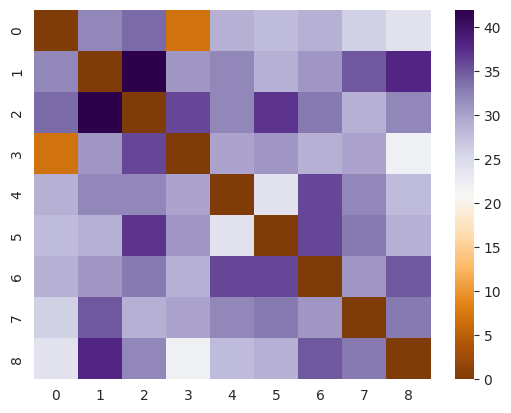

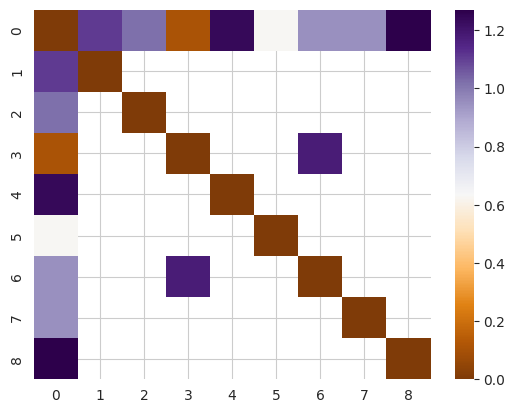

In [111]:
make_distance_plot("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff3600/0/")

# Single instance optimization

## 152

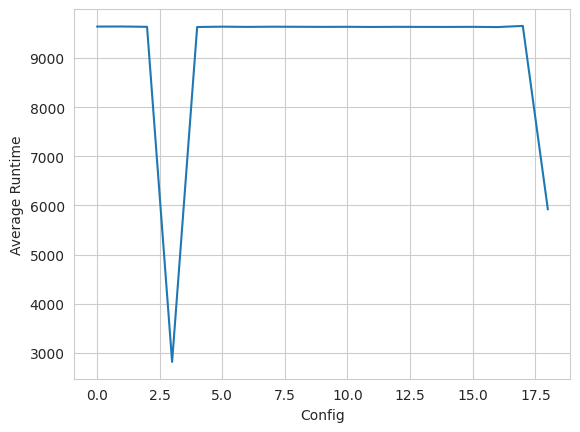

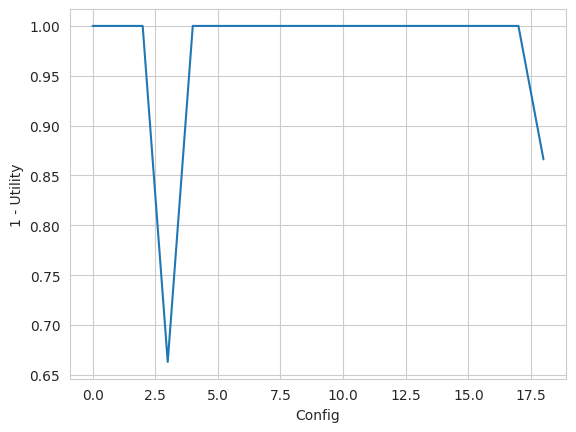

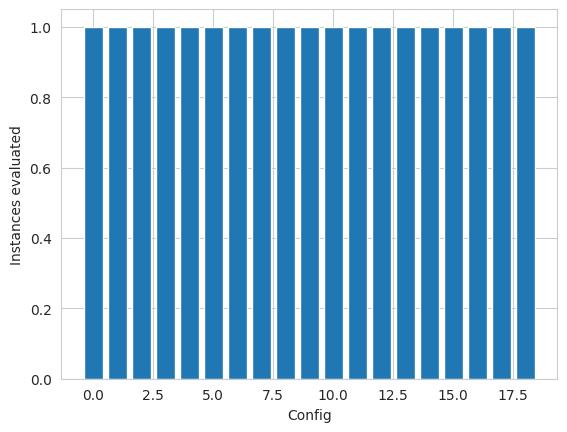

In [76]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_utility_9600_instance152/0/")

aggregate              object
auto_aggfill_on        object
auto_barcorrectors     object
auto_barhomogeneous    object
auto_barorder          object
                        ...  
impliedcuts            object
presolve               object
gubcovercuts           object
startnodelimit         object
strongcgcuts           object
Length: 111, dtype: object
{'auto_projimpliedcuts_on', 'partitionplace', 'barorder', 'aggregate', 'auto_mircuts_on', 'auto_disconnected_on', 'auto_networkcuts_on', 'auto_varbranch_on', 'auto_strongcgcuts_on', 'auto_zeroobjnodes_on', 'auto_minrelnodes_on', 'shut_off_mip_start_processing', 'auto_cutpasses_on', 'auto_presparsify_on', 'auto_branchdir_on', 'siftmethod', 'branchdir', 'precrush', 'quad', 'auto_infproofcuts_on', 'barhomogeneous', 'auto_cliquecuts_on', 'auto_quad_on', 'auto_mipsepcuts_on', 'auto_rltcuts_on', 'presparsify', 'infunbdinfo', 'auto_barhomogeneous', 'auto_sifting_on', 'dualreductions', 'auto_aggfill_on', 'auto_cuts_on', 'auto_submipcuts_on', '

/tmp/ipykernel_10970/347920964.py:11: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


[[ 0. 32. 34.  7. 29. 28. 29. 26. 24. 30. 33. 29. 27. 27. 26. 35. 29. 27.
  32.]
 [ 0.  0. 42. 31. 32. 29. 31. 35. 38. 32. 30. 10. 34. 34. 40. 27. 29. 37.
  31.]
 [ 0.  0.  0. 36. 32. 37. 33. 29. 32. 35. 28. 42. 31. 32. 35. 36. 31. 30.
  37.]
 [ 0.  0.  0.  0. 30. 31. 29. 30. 22. 29. 33. 26. 25. 28. 25. 33. 31. 26.
  31.]
 [ 0.  0.  0.  0.  0. 24. 36. 32. 28. 27. 32. 31. 35. 29. 38. 30. 27. 32.
  29.]
 [ 0.  0.  0.  0.  0.  0. 36. 33. 29.  7. 33. 34. 35. 31. 33. 30. 27. 37.
  26.]
 [ 0.  0.  0.  0.  0.  0.  0. 31. 35. 35. 33. 32. 31. 39. 29. 29. 29. 27.
  33.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 33. 37. 26. 35. 14. 32. 31. 32. 29. 30.
  37.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 27. 34. 38. 29. 25. 23. 30. 37. 25.
  25.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 29. 34. 31. 28. 30. 29. 32. 36.
  25.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 32. 24. 32. 33. 28. 30. 30.
  41.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 33. 31. 37. 29. 29. 34.
  29.]
 [ 0.  0.  0.  0.  0.  0.  0

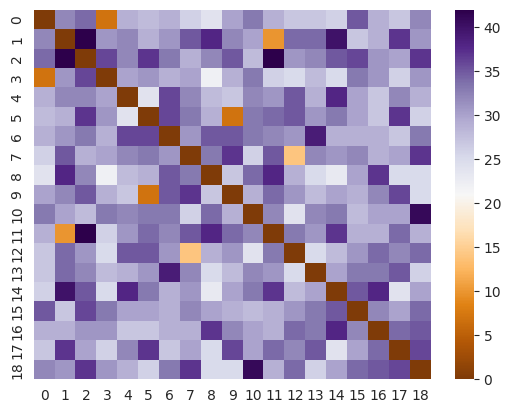

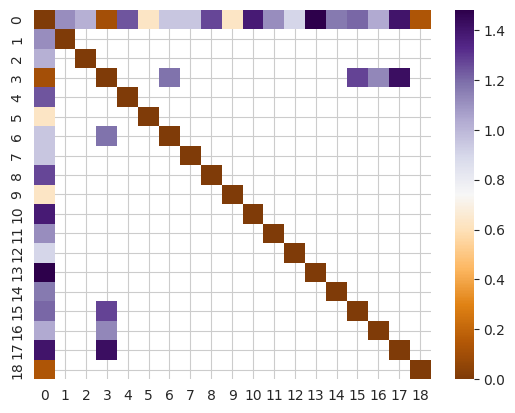

In [112]:
make_distance_plot("./storage_alice/smac3_output/smac3_mipverify_utility_9600_instance152/0/")

## 566 old intesifier

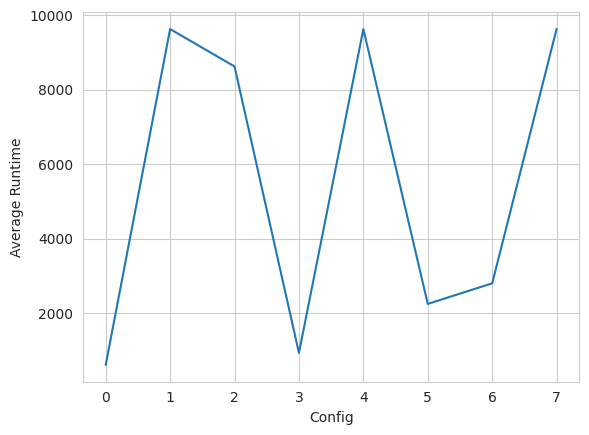

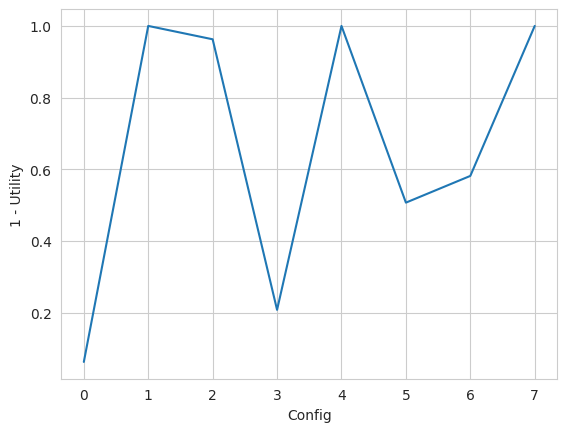

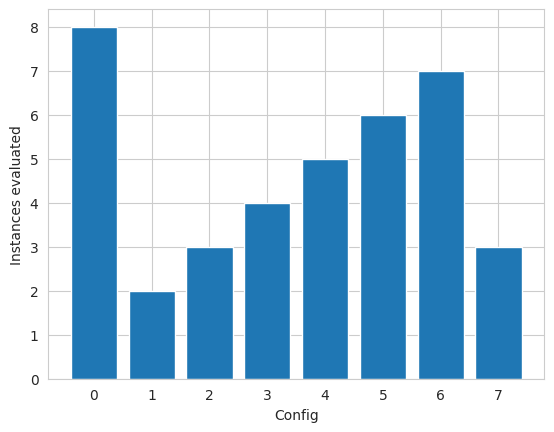

In [78]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_utility_9600_instance566/0/")

aggregate              object
auto_aggfill_on        object
auto_barcorrectors     object
auto_barhomogeneous    object
auto_barorder          object
                        ...  
impliedcuts            object
presolve               object
gubcovercuts           object
startnodelimit         object
strongcgcuts           object
Length: 111, dtype: object
{'auto_projimpliedcuts_on', 'partitionplace', 'barorder', 'aggregate', 'auto_mircuts_on', 'auto_disconnected_on', 'auto_networkcuts_on', 'auto_varbranch_on', 'auto_strongcgcuts_on', 'auto_zeroobjnodes_on', 'auto_minrelnodes_on', 'shut_off_mip_start_processing', 'auto_cutpasses_on', 'auto_presparsify_on', 'auto_branchdir_on', 'siftmethod', 'branchdir', 'precrush', 'quad', 'auto_infproofcuts_on', 'barhomogeneous', 'auto_cliquecuts_on', 'auto_quad_on', 'auto_mipsepcuts_on', 'auto_rltcuts_on', 'presparsify', 'infunbdinfo', 'auto_barhomogeneous', 'auto_sifting_on', 'dualreductions', 'auto_aggfill_on', 'auto_cuts_on', 'auto_submipcuts_on', '

/tmp/ipykernel_10970/347920964.py:11: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


[[ 0. 32. 34.  7. 29. 28. 29. 26.]
 [ 0.  0. 42. 31. 32. 29. 31. 35.]
 [ 0.  0.  0. 36. 32. 37. 33. 29.]
 [ 0.  0.  0.  0. 30. 31. 29. 30.]
 [ 0.  0.  0.  0.  0. 24. 36. 32.]
 [ 0.  0.  0.  0.  0.  0. 36. 33.]
 [ 0.  0.  0.  0.  0.  0.  0. 31.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]


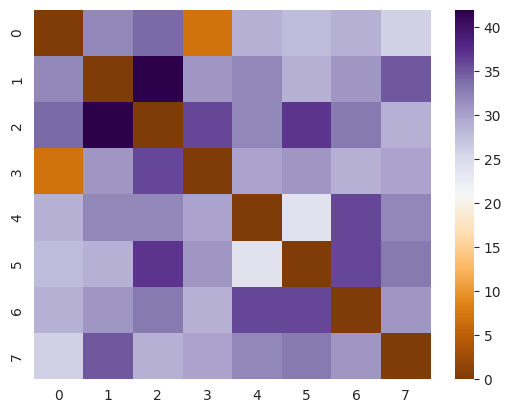

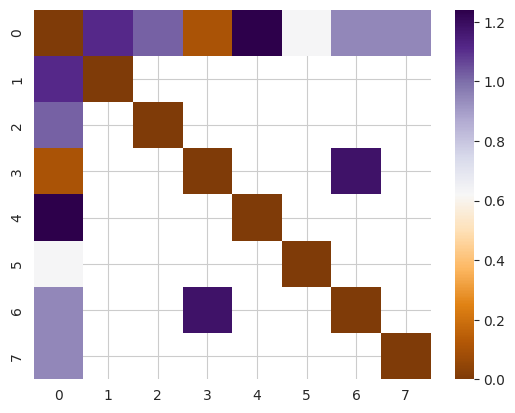

In [113]:
make_distance_plot("./storage_alice/smac3_output/smac3_mipverify_utility_9600_instance566/0/")

## 566 new intensifier

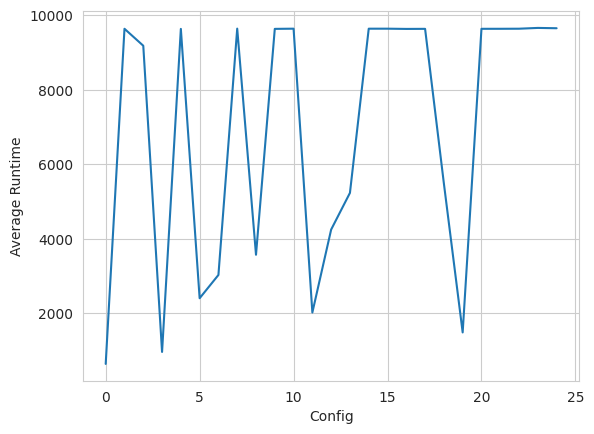

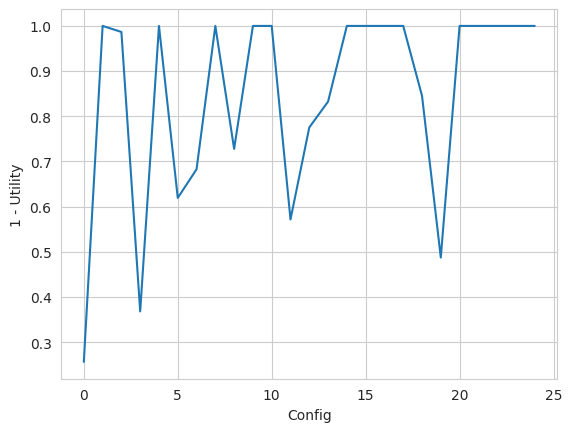

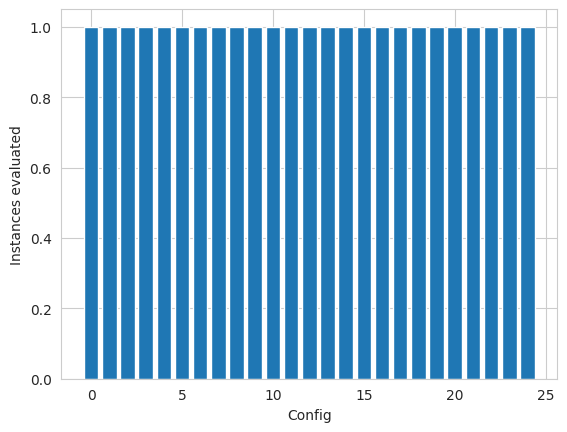

In [114]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_utility_9600_instance566_new_intesifier/0/")

aggregate              object
auto_aggfill_on        object
auto_barcorrectors     object
auto_barhomogeneous    object
auto_barorder          object
                        ...  
impliedcuts            object
presolve               object
gubcovercuts           object
startnodelimit         object
strongcgcuts           object
Length: 111, dtype: object
{'auto_projimpliedcuts_on', 'partitionplace', 'barorder', 'aggregate', 'auto_mircuts_on', 'auto_disconnected_on', 'auto_networkcuts_on', 'auto_varbranch_on', 'auto_strongcgcuts_on', 'auto_zeroobjnodes_on', 'auto_minrelnodes_on', 'shut_off_mip_start_processing', 'auto_cutpasses_on', 'auto_presparsify_on', 'auto_branchdir_on', 'siftmethod', 'branchdir', 'precrush', 'quad', 'auto_infproofcuts_on', 'barhomogeneous', 'auto_cliquecuts_on', 'auto_quad_on', 'auto_mipsepcuts_on', 'auto_rltcuts_on', 'presparsify', 'infunbdinfo', 'auto_barhomogeneous', 'auto_sifting_on', 'dualreductions', 'auto_aggfill_on', 'auto_cuts_on', 'auto_submipcuts_on', '

/tmp/ipykernel_10970/347920964.py:11: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


[[ 0. 32. 34.  7. 29. 28. 29. 26. 24. 35. 33. 26. 32. 25. 35. 35. 29. 27.
  37. 28. 28. 30. 27. 26. 28.]
 [ 0.  0. 42. 31. 32. 29. 31. 35. 38. 35. 30. 35.  7. 29. 36. 27. 29. 37.
  28. 31. 32. 28. 31. 31. 33.]
 [ 0.  0.  0. 36. 32. 37. 33. 29. 32. 27. 28. 34. 38. 35. 36. 36. 31. 30.
  36. 37. 34. 32. 37. 32. 28.]
 [ 0.  0.  0.  0. 30. 31. 29. 30. 22. 34. 33. 29. 31. 27. 33. 33. 31. 26.
  34. 32. 29. 33. 27. 30. 28.]
 [ 0.  0.  0.  0.  0. 24. 36. 32. 28. 29. 32. 24. 31. 36. 30. 30. 27. 32.
  34. 27. 25. 34. 34. 34. 26.]
 [ 0.  0.  0.  0.  0.  0. 36. 33. 29. 34. 33.  6. 29. 33. 29. 30. 27. 37.
  32. 25. 31. 29. 31. 30. 29.]
 [ 0.  0.  0.  0.  0.  0.  0. 31. 35. 30. 33. 38. 30. 28. 33. 29. 29. 27.
  32. 32. 36. 29. 33. 28. 30.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 33. 36. 26. 31. 33. 28. 34. 32. 29. 30.
  33. 32. 32. 33. 26. 34. 27.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 27. 34. 23. 37. 39. 28. 30. 37. 25.
  30. 29. 33. 30. 25. 36. 32.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 34. 31. 32. 3

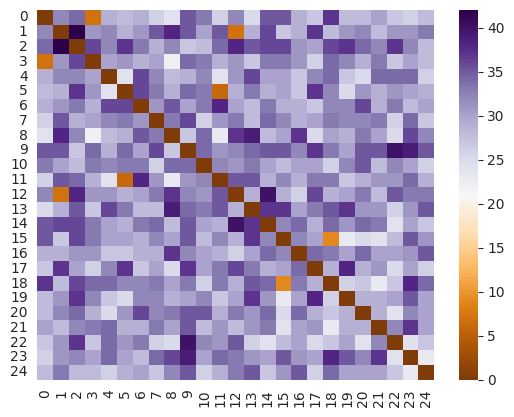

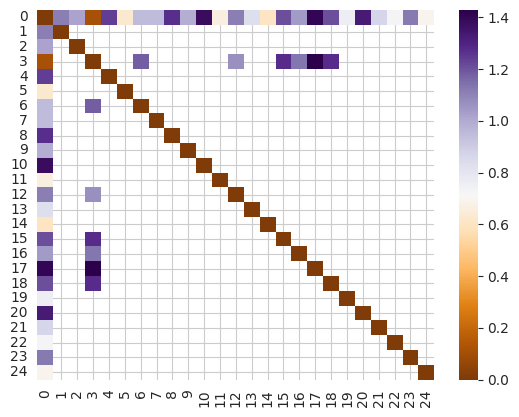

In [115]:
make_distance_plot("./storage_alice/smac3_output/smac3_mipverify_utility_9600_instance566_new_intesifier/0/")